In [1]:
import agama
import matplotlib.pyplot as plt 
import numpy as np 
from scipy import optimize
from matplotlib.patches import Rectangle, Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})
agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Msun

In [2]:
def pot_eff(pot,omega,pos):
    potential=pot.potential(pos)
    if pos.ndim==1:
        CENTRIFUGAL = (1/2)*omega**2 * (pos[0]**2 + pos[1]**2)
    else: 
        CENTRIFUGAL = (1/2)*omega**2 * (pos[:,0]**2 + pos[:,1]**2)
    return potential-CENTRIFUGAL

def force_eff(pot,omega,pos):
    f = pot.force(pos)
    if pos.ndim==1:
        f[:, 0] += omega**2 * pos[0]
        f[:, 1] += omega**2 * pos[1]
    else:
        f[:, 0] += omega**2 * pos[:, 0]
        f[:, 1] += omega**2 * pos[:, 1]
    return f


make grid

In [3]:
npoints=100
xmin,xmax = -15,15
xs,ys=np.linspace(xmin,xmax,npoints),np.linspace(xmin,xmax,npoints)
XS,YS = np.meshgrid(xs,ys)
xxs,yys = XS.flatten(),YS.flatten()
zzs = np.zeros_like(xxs)
points = np.vstack((xxs,yys,zzs)).T

make a simple bar 

In [4]:
omega = 37.5
pot=agama.Potential(type="Ferrers", mass=1e10, scaleRadius=3.5,axisRatioY=1/3, axisRatioZ=1/4)

get the energy levels of our favorite lagrange points

In [5]:
fx = lambda x: force_eff(pot, omega, np.array([[x, 0., 0.]]))[0, 0]
fy = lambda y: force_eff(pot, omega, np.array([[0., y, 0.]]))[0, 1]
xL1 = optimize.brentq(fx, .1, 12)      # bracket needs a sign change
yL4 = optimize.brentq(fy, .1, 12)      # bracket needs a sign change
EL1=pot_eff(pot,omega,np.array([xL1,0,0]))
EL4=pot_eff(pot,omega,np.array([0,yL4,0]))

[None]

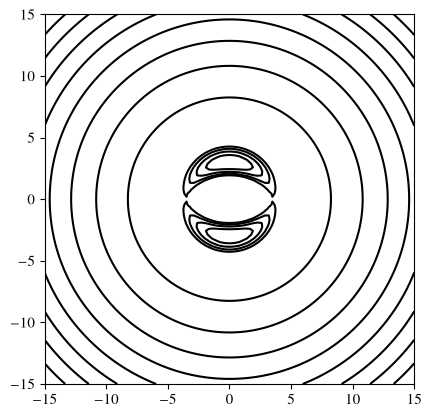

In [6]:
potential=pot.potential(points)
POT=np.reshape(potential,XS.shape)
CENTRIFUGAL = (1/2)*omega**2 * (XS**2 + YS**2)
pot_total = POT-CENTRIFUGAL
contours = np.linspace(pot_total.min(),pot_total.max(),10)
contours=np.concatenate((contours,np.linspace(EL1*(1+.4e-3),EL4,5)))
contours=np.sort(contours)
fig,axis=plt.subplots(1,1)
axis.contour(XS,YS,POT-CENTRIFUGAL,levels=contours,colors="k",linestyle="-");
axis.set(aspect="equal")

## TRY A REALISITIC BAR 

Coleman: 

$$\rho_1(x,y,z) = \rho \rm{sech}\left(a^m\right)\times\left[1+\alpha\left(e^{-a^n_{+}} +e^{-a^n_{-}}\right)\right]e^{-\left(\frac{r}{r_{\rm{cut}}}\right)^2}  $$


from portal et al 2015. 

$$\rho_{\rm{bar}}(x,y,z) = \rho_i e^{-a_i^{n_i}} \rm{sech}^2\left(\frac{z}{z_i}
\right) \times e^{\left(\frac{R_i}{R_{i,out}}\right)^{n_{\rm{i,out}}}} e^{-\left(\frac{R_{\rm{i,in}}}{R}\right)^{n_{\rm{i,in}}}}$$

where 

$$a_i = \left[\left(\frac{|x|}{x_i}\right)^{c_{\perp,i}} + \left(\frac{|y|}{y_i}\right)^{c_{\perp,i}}\right]^{\frac{1}{c_{\perp,i}}}$$

In [7]:
# let's do the bar from this paper I found 
## COLEMAN PARAMETERS !! DISGUSTING !!
coleman_components=dict(\
    alpha = 0.626,
    c = 1.342 ,
    x1 = 0.49 ,
    y1 = 0.392,
    z1 = 0.229,
    xc = 0.751,
    yc = 0.469,
    cperp = 2.232,
    cparallel = 1.991,
    m = 0.873,
    n = 1.94,
    rcut = 4.37,
    rho_c = 3.16e9,)

portail_components = {
    "component2": dict(rho_i=0.5e9,    
                       xi=5.364, 
                       yi=0.959, 
                       zi=0.611,
                       R_in=0.558, 
                       R_out=3.19,  
                       cperp=0.97,  
                       n_in=3.196, 
                       n_out=16.731,  
                       n_a=1.0),
    "component3": dict(rho_i=1.743e13, 
                       xi=0.478, 
                       yi=0.297, 
                       zi=0.252,
                       R_in=7.607, 
                       R_out=2.204, 
                       cperp=1.879, 
                       n_in=1.63, 
                       n_out=-27.291,
                       n_a=1.0),}

def coleman2020(alpha, c, x1, y1, z1, xc, yc, cperp, cparallel, m, n, rcut, rho_c):
    # for agama, density normalization is one!
    # il numero di parametri in questo modello e' un offeso a dio ! opinione mio !
    def rho(xyz):
        x, y, z = xyz.T
        a = (((np.abs(x) / x1)**(cperp) + (np.abs(y) / y1)**(cperp))**(cparallel/cperp) + (np.abs(z)/z1)**cparallel)**(1/cparallel)
        aplus  = (((x+c*z)/xc)**2 + (y/yc)**2)**(1/2)
        aminus = (((x-c*z)/xc)**2 + (y/yc)**2)**(1/2)
        r = np.sqrt(x**2 + y**2 + z**2)
        return  (rho_c / np.cosh(a**m)) * (1 + alpha*(np.exp(-aplus**n) + np.exp(-aminus**n))) * np.exp(-(r/rcut)**2)
    return rho

# !!! THIS BAR IS A 20 PARAMETER MODEL!!!!
def portail_component(rho_i, xi, yi, zi, R_in, R_out, cperp, n_in, n_out, n_a):
    def rho(xyz):
        x, y, z = xyz.T
        R = np.sqrt(x**2 + y**2)
        a = ((np.abs(x)/xi)**cperp + (np.abs(y)/yi)**cperp)**(1/cperp)
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            inner = np.exp(-(R_in/R)**n_in)
            outer = np.exp(-(R/R_out)**n_out)
        inner = np.nan_to_num(inner)
        outer = np.nan_to_num(outer)
        return rho_i * np.exp(-a**n_a) / np.cosh(z/zi)**2 * outer * inner
    return rho

bar1=coleman2020(**coleman_components)
bar2=portail_component(**portail_components['component2'])
bar3=portail_component(**portail_components['component3'])

In [8]:
pbar1 = agama.Potential(type='CylSpline', density=bar1,symmetry='triaxial',mmax=8,gridSizeR=40, gridSizeZ=40, Rmin=0.001, Rmax=20, Zmin=0.001, Zmax=20,)
pbar2 = agama.Potential(type='CylSpline', density=bar2,symmetry='triaxial',mmax=8,gridSizeR=40, gridSizeZ=40, Rmin=0.001, Rmax=20, Zmin=0.001, Zmax=20,)
pbar3 = agama.Potential(type='CylSpline', density=bar3,symmetry='triaxial',mmax=8,gridSizeR=40, gridSizeZ=40, Rmin=0.001, Rmax=20, Zmin=0.001, Zmax=20,)

## Add the axisymmetric components

supermassive black hole

In [9]:
supermassiveblackhole = dict(type='Plummer', mass=4.154e6,scaleRadius=1e-4)
psagA=agama.Potential(**supermassiveblackhole)

nuclear star cluster 
$$ \rho = \frac{(3-\gamma)M}{4\pi q} \frac{a_o}{a^\gamma (a+a_0)^{4-\gamma}} $$

In [10]:
nsc = dict(type='Dehnen', mass=6.1e7, gamma=0.71, scaleRadius=5.9e-3, axisRatioZ=0.73)
pnsc = agama.Potential(**nsc)

nuclear stellar disk
$$ \rho = \rho_1 \exp\left[-\left(\frac{a}{R_1}\right)^{n_1}\right] + \rho_2 \exp\left[-\left(\frac{a}{R_2}\right)^{n_2}\right]$$
Where $a$ is the spheroidal radius: $a^2 = R^2 + \frac{z^2}{q^2}$

In [11]:
NSD1 = dict(type='Spheroid', 
     densityNorm=1.311 * 153e10,
     gamma=0, 
     beta=0, 
     alpha=1, 
     scaleRadius=1,
     outerCutoffRadius=5.06e-3,
     cutoffStrength=0.72,
     axisRatioZ=0.37)

NSD2 = dict(type='Spheroid', 
     densityNorm=153e10,
     gamma=0, 
     beta=0, 
     alpha=1, 
     scaleRadius=1, # dummy, no power law comp
     outerCutoffRadius=24.6e-3,
     cutoffStrength=0.79,
     axisRatioZ=0.37)

pnsd1 = agama.Potential(**NSD1)
pnsd2 = agama.Potential(**NSD2)

The galactic disks!

In [12]:
DISK1 = dict(
    type = "Disk",
    surfaceDensity = 1.3719e3 * 1e6,
    scaleRadius = 2,
    scaleHeight = 300e-3,
    innerCutoffRadius=2.4
)
DISK2= dict(
    type = "Disk",
    surfaceDensity = 9.2391e2 * 1e6,
    scaleRadius = 2.8,
    scaleHeight = 900e-3,
    innerCutoffRadius=2.4
)

pdisk1 = agama.Potential(**DISK1)
pdisk2 = agama.Potential(**DISK2)

gas disk

$$\rho = \frac{\Sigma}{4h}\exp\left[-\frac{R_d}{R} - \frac{R}{R_s}\right] \mathrm{sech}^2 (z/2h)$$


In [13]:
GDISK1 = dict(
    type = "Disk",
    surfaceDensity = 53.1 * 1e6,
    scaleRadius = 7,
    scaleHeight = -85e-3,
    innerCutoffRadius=4
)

GDISK2 = dict(
    type = "Disk",
    surfaceDensity = 2.18e3 * 1e6,
    scaleRadius = 1.2,
    scaleHeight = -45e-3,
    innerCutoffRadius=12
)
pgdisk1=agama.Potential(**GDISK1)
pgdisk2=agama.Potential(**GDISK2)

The einasto dark matter profile

$$\rho(r) = \rho \exp\left[-\left(\frac{r}{a}\right)^{1/n}\right]$$

In [14]:
n=4.5
rs = 96
a = rs*(3*n-1/3)**(-n)
EINASTO = dict(type='Spheroid', mass=1.1e12,
               gamma=0, beta=0, alpha=1, scaleRadius=1,    # dummies: factor is 1
               outerCutoffRadius=a, cutoffStrength=1/n)     # axis ratios default to 1 (spherical)
phalo = agama.Potential(**EINASTO)

ignore the spiral arms for now, it's too much

In [15]:
omega = 37.5
ptot = agama.Potential(pbar1,
                       pbar2,
                       pbar3,
                       psagA,
                       pnsc,
                       pnsd1, 
                       pnsd2, 
                       pdisk1, 
                       pdisk2,
                       pgdisk1,
                       pgdisk2,
                       phalo)

In [16]:
# lets look at the effective potential! 
peff=pot_eff(ptot,omega,points)
# get the lagrange points
fx = lambda x: force_eff(ptot, omega, np.array([[x, 0., 0.]]))[0, 0]
fy = lambda y: force_eff(ptot, omega, np.array([[0., y, 0.]]))[0, 1]
xL1 = optimize.brentq(fx, 3, 12)      # bracket needs a sign change
yL4 = optimize.brentq(fy, 3, 12)      # bracket needs a sign change
EL1=pot_eff(ptot,omega,np.array([xL1,0,0]))
EL4=pot_eff(ptot,omega,np.array([0,yL4,0]))

In [17]:
contours = np.linspace(peff.min(),peff.max(),13)
contours=np.concatenate((contours,np.linspace(EL1*(1+.4e-3),EL4,4)))
contours=np.sort(contours)

[None,
 Text(0.5, 1.0, 'Bar-Frame Milky Way Effective Potential, Hunter et al. (2024)'),
 Text(0.5, 0, 'x [kpc]'),
 Text(0, 0.5, 'y [kpc]')]

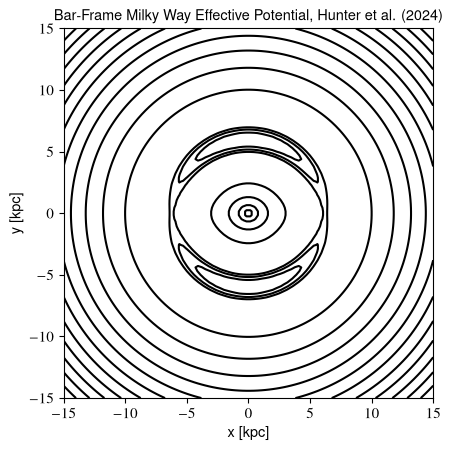

In [18]:
fig,axis=plt.subplots(1,1)
axis.contour(XS,YS,np.reshape(peff,XS.shape),levels=contours,colors="k",linestyle="-");
axis.set(aspect="equal",title="Bar-Frame Milky Way Effective Potential, Hunter et al. (2024)",xlabel="x [kpc]", ylabel="y [kpc]")

## Analyze the bar orbits 
1. Pick a jacobi energy
2. study the zero velocity surface 
3. sample the initial conditions in this space
4. make the surface of section 

In [19]:
xmax = 3*xL1
E0=pot_eff(ptot,omega,np.array([1e-1,0,0]))
Ej = (49/50)*(EL1-E0) + E0
xs = np.linspace(1e-3,xmax,100)

# find the intersection point :
x_max_EJ = lambda x, Ej, ptot, omega: pot_eff(ptot,omega, np.array([x,0,0])) - Ej
# optimize.minimize(f,2,args=(Emid, ptot, omega))
x_zvc=optimize.brenth(x_max_EJ,.2,xL1,args=(Ej ,ptot,omega))
x_zvc_beyond=optimize.brenth(x_max_EJ,xL1,xmax,args=(Ej ,ptot,omega))

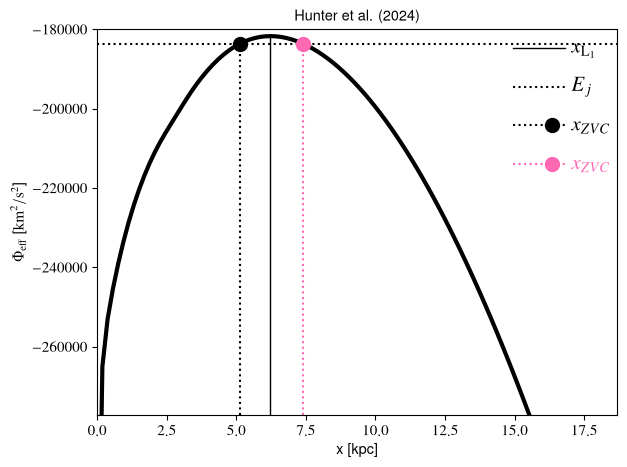

In [20]:
fig,axis=plt.subplots(1,1)
axis.plot(xs,pot_eff(ptot,omega,np.array([xs,np.zeros_like(xs),np.zeros_like(xs)]).T),color="k",linewidth=3)
axis.set(xlim=[0,xmax],ylim=[E0,EL1*.99],xlabel="x [kpc]",ylabel=r"$\Phi_{\rm{eff}}$ [$\rm{{km}}^2/\rm{{s}}^2$]",title="Hunter et al. (2024)");

# for the legend
xpos=0.9125
ypos = 0.95
delta_y = 0.1

fig.tight_layout()
fig.savefig("phi_eff_hunter_2024_frame1.png",dpi=300)

axis.vlines(xL1,E0,EL1,color="k",linestyles="-",linewidth=1)
axis.plot([.8,.9],[ypos,ypos],color="k",linestyle="-",transform=axis.transAxes,linewidth=1)
axis.text(xpos, ypos,s=r"$x_{\rm{L_{1}}}$",transform=axis.transAxes,ha="left", va="center",fontsize=15)
fig.savefig("phi_eff_hunter_2024_frame2.png",dpi=300)

axis.hlines(Ej ,0,xmax,color="k",linestyles=":")
axis.plot([.8,.9],[ypos-delta_y,ypos-delta_y],color="k",linestyle=":",transform=axis.transAxes)
axis.text(xpos,ypos-delta_y,s=r"$E_j$",transform=axis.transAxes,ha="left", va="center",fontsize=15)
fig.savefig("phi_eff_hunter_2024_frame3.png",dpi=300)

axis.vlines(x_zvc, E0, Ej, linestyles=":", color="k")
axis.scatter(x_zvc, Ej, s=100,zorder=10,color="k")
axis.text(xpos,ypos-2*delta_y,s=r"$x_{ZVC}$",transform=axis.transAxes,ha="left", va="center",fontsize=15)
axis.plot([.8,.9],[ypos-2*delta_y,ypos-2*delta_y],color="k",linestyle=":",transform=axis.transAxes)
axis.scatter(.875,ypos-2*delta_y, s=100,zorder=10,color="k",transform=axis.transAxes)
fig.savefig("phi_eff_hunter_2024_frame4.png",dpi=300)

# now, what if we were beyond? 
axis.vlines(x_zvc_beyond, E0, Ej, linestyles=":", color="hotpink")
axis.scatter(x_zvc_beyond, Ej, s=100,zorder=10,color="hotpink")
axis.text(xpos,ypos-3*delta_y,s=r"$x_{ZVC}$",transform=axis.transAxes,ha="left", va="center",fontsize=15, fontdict=dict(color="hotpink"))
axis.plot([.8,.9],[ypos-3*delta_y,ypos-3*delta_y],color="hotpink",linestyle=":",transform=axis.transAxes)
axis.scatter(.875, ypos-3*delta_y, s=100,zorder=10,color="hotpink",transform=axis.transAxes)
fig.savefig("phi_eff_hunter_2024_frame5.png",dpi=300)

The zero-velocity curve occurs when all of the energy is in the effective potential. Thus, at this point, you'd need imaginary velocity! that doesn't make sense! velocity is a real number, so, that defines the forbidden zone. Also, this is when you start to figure out more about your dynamical system. 

So, I need to write it as... 

$$ E_j= \frac{1}{2}\left(\dot{x}^2 + \dot{y}^2 \right) + \Phi_{\rm{eff}}(x,y) $$

Since $T>0$, then, $\left(E_j -\Phi_{\rm{eff}}(x,y)\right) > 0$ or else!

$$\frac{1}{2}\left(\dot{x}^2 + \dot{y}^2 \right) =  E_j - \Phi_{\rm{eff}}(x,y) $$

Imagine the situation when $y=0$ and $\dot{y}=0$

$$\dot{x} = \sqrt{2\cdot\left( E_j - \Phi_{\rm{eff}}(x,0)\right)} $$


In [21]:
xdot_zvc = lambda x, pot, omega, Ej, : np.sqrt(2*(Ej- pot_eff(pot,omega,np.array([x,np.zeros_like(x),np.zeros_like(x)]).T) ))
xxs=np.linspace(-0.9999*x_zvc, .9999*x_zvc,301)
xxdot=xdot_zvc(xxs, ptot, omega, Ej)

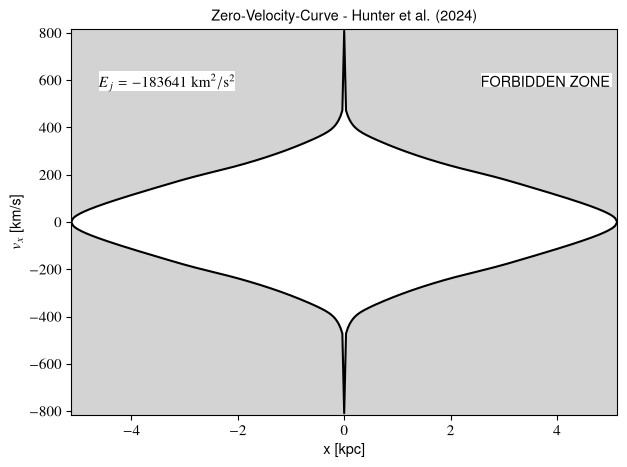

In [22]:
# I close my polygon 
xx_all = np.concatenate((xxs, xxs[::-1]))
xdotall = np.concatenate((xxdot, -xxdot[::-1]))

fig, ax = plt.subplots(1,1)

# 1) plot your curve
ax.plot(xx_all, xdotall, color="k")

# set limits first (so "outside" means full visible axes)
ax.set_xlim(xx_all.min(), xx_all.max())
ax.set_ylim(1.01*xdotall.min(), 1.01*xdotall.max())

ax.set(
    xlabel="x [kpc]",
    ylabel=r"$v_x$ [km/s]",
    title="Zero-Velocity-Curve - Hunter et al. (2024)"
)

fig.tight_layout()
fig.savefig("zero_velocity_curve_panel0.png", dpi=300)

# add what the Jacobi energy
xpos,ypos=0.05,0.85
ax.add_patch(Rectangle((xpos,ypos-.01),0.25,0.05,facecolor="white",transform=ax.transAxes))
ax.text(xpos,ypos,s=r"$E_j = {{{:.0f}}}~\rm{{km}}^2/\rm{{s}}^2$ ".format(Ej),transform=ax.transAxes,ha="left")
fig.savefig("zero_velocity_curve_panel1.png", dpi=300)


# 2) gray full-axes background (in axes coordinates)
ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                       facecolor="lightgray", edgecolor="none", zorder=0))

# 3) white polygon hole (in data coordinates)
ax.add_patch(Polygon(np.c_[xx_all, xdotall], closed=True,
                     facecolor="white", edgecolor="none", zorder=1))



xpos,ypos=0.75,0.85
ax.add_patch(Rectangle((0.75,0.85),0.24,0.035,facecolor="white",transform=ax.transAxes))
ax.text(0.75,0.85,s="FORBIDDEN ZONE",transform=ax.transAxes,ha="left")
fig.savefig("zero_velocity_curve_panel2.png", dpi=300)

Let's see how this changes, as we increase the energy 


In [23]:
my_xdots=[]
my_xs=[]
Ejs=np.geomspace(E0/2 + E0/2 ,(19/20)*EL1,20)
for i in range(len(Ejs)):
    try:
        x_zvc=optimize.brenth(x_max_EJ,00,.99*xL1,args=(Ejs[i] ,ptot,omega))
        xsampling = np.linspace(-0.999*x_zvc, .999*x_zvc,301)
        xxdot=xdot_zvc(xsampling, ptot, omega, Ejs[i])
        my_xs.append(np.concatenate((xsampling,xsampling[::-1])))
        my_xdots.append(np.concatenate((xxdot,-xxdot[::-1])))
    except:
        print(i)
        continue

17
18
19


In [24]:
CMAP=plt.cm.rainbow
NORM=Normalize(vmin=E0/1e4,vmax=EL1/1e4)

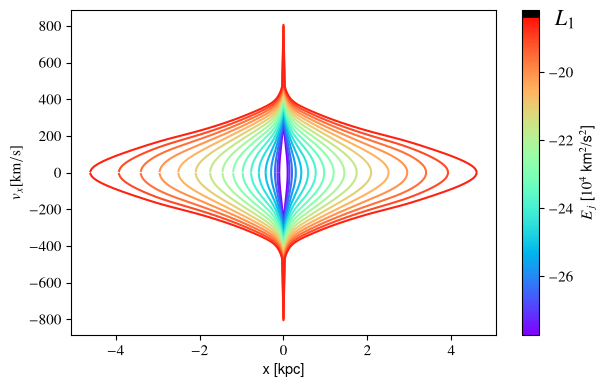

In [25]:
fig,axis=plt.subplots(1,1,figsize=(8.25-2,4))
axis.set(xlabel="x [kpc]", ylabel=r"$v_x [\rm{km}/\rm{s}]$")
i=0
frame_index = 0
axis.plot(my_xs[i],my_xdots[i],color=CMAP(NORM(Ejs[i]/1e4)))
fig.tight_layout()
colorbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP),ax=axis,label=r"$E_j$ [$10^4$ km$^{2}$/s$^{2}$]",)
fname = "zero_velocity_curve_{:d}.png"
fig.savefig(fname.format(frame_index),dpi=300)
frame_index+=1
colorbar.ax.axhline(EL1/1e4, color="black", linewidth=10.5, zorder=12)
colorbar.ax.text(2,1,r"$L_1$",transform=colorbar.ax.transAxes,ha="left",va="top",fontdict=dict(fontsize=16))
fig.savefig(fname.format(frame_index),dpi=300)
frame_index+=1
for i in range(1,len(my_xs)):
    axis.plot(my_xs[i],my_xdots[i],color=CMAP(NORM(Ejs[i]/1e4)))
    fig.savefig(fname.format(frame_index),dpi=300)
    frame_index+=1


## View the surface of section plots

In [26]:
# redefine the functions for finding the lagrange points 
fx = lambda x: force_eff(ptot, omega, np.array([[x, 0., 0.]]))[0, 0]
fy = lambda y: force_eff(ptot, omega, np.array([[0., y, 0.]]))[0, 1]
# redefine the function for getting the maxmum distance for a given energy 
x_max_EJ = lambda x, Ej, ptot, omega: pot_eff(ptot,omega, np.array([x,0,0])) - Ej
# redefine the functions the zero velocity-curve
zero_velocity_curve = lambda x, pot, omega, Ej, : np.sqrt(2*(Ej- pot_eff(pot,omega,np.array([x,np.zeros_like(x),np.zeros_like(x)]).T) ))

def sample_initial_conditions_planar(potential,omega,Ej,norbits=50,seed=10):
    # Get the maximum extent in x, when kinetic energy is zero 
    x_max_EJ = lambda x, Ej, pot, omega: pot_eff(pot,omega, np.array([x,0,0])) - Ej
    x_zvc=optimize.brenth(x_max_EJ,.2,xL1,args=(Ej,potential,omega))
    xdot_zvc = lambda x, pot, omega, Ej, : np.sqrt(2*(Ej- pot_eff(pot,omega,np.array([x,np.zeros_like(x),np.zeros_like(x)]).T) ))
    # pick a random x between these two 
    rng = np.random.default_rng(seed=seed)
    k = 0 
    initial_conditions = np.zeros((norbits,6))
    while (k<norbits):
        xtest=rng.uniform(-x_zvc,x_zvc)
        # now, see the available kinetic energy 
        T = Ej - pot_eff(potential,omega,np.array([xtest,0,0]))
        # create a velocity between this and the vmax
        vxmax = xdot_zvc(xtest,potential,omega,Ej)
        vxtest = rng.uniform(-vxmax,vxmax)
        additional_energy = T - (vxtest**2)/2
        vytest = np.sqrt(2*additional_energy)
        initial_conditions[k] = [xtest,0,0,vxtest,vytest,0]
        k+=1
    return initial_conditions

In [27]:
xL1 = optimize.brentq(fx, 3, 12)      # bracket needs a sign change
yL4 = optimize.brentq(fy, 3, 12)      # bracket needs a sign change
EL1=pot_eff(ptot,omega,np.array([xL1,0,0]))
EL4=pot_eff(ptot,omega,np.array([0,yL4,0]))
E0 =pot_eff(ptot,omega,np.array([0,0,0]))
print(xL1)

6.227307125173754


In [28]:
# pick jacobii energy and find the critical values
Ej = (49/50) * (EL1-E0) + E0
x_zvc=optimize.brenth(x_max_EJ,.2,xL1,args=(Ej ,ptot,omega))
print(x_zvc)
x_trace = np.linspace(-(1-1e-3)*x_zvc,(1-1e-3)*x_zvc,401)
vx_max = zero_velocity_curve(x_trace, ptot, omega, Ej)
# sample the initial conditions radonmly
initial_conditions = sample_initial_conditions_planar(ptot,omega,Ej,seed=107,norbits=130)
# get the envelope for the plot 
envlope_x = np.concatenate((x_trace,x_trace[::-1], [x_trace[0]]))
envlope_vx = np.concatenate((vx_max,-vx_max[::-1], [vx_max[0]]))

4.244899879167106


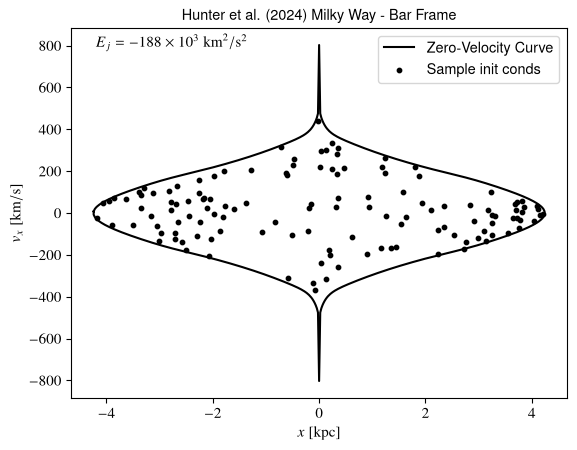

In [29]:
fig,axis=plt.subplots(1,1)
axis.plot(envlope_x,envlope_vx,color="k",label="Zero-Velocity Curve")
axis.text(0.05,0.95,s=r"$E_j={{{:.0f}}}\times10^3~\rm{{km}}^2/\rm{{s}}^2$".format(Ej/1e3),transform=axis.transAxes)
axis.scatter(initial_conditions[:,0],initial_conditions[:,3],s=10,c="k", label="Sample init conds")
axis.set(ylabel=r"$v_x~[\rm{km}/\rm{s}]$",xlabel=r"$x~[\rm{kpc}]$",title="Hunter et al. (2024) Milky Way - Bar Frame")
axis.legend()

Solve their orbits!

In [30]:
timestamps,orbits=agama.orbit(ic=initial_conditions,potential=ptot,Omega=omega,time=2,trajsize=int(1e3),separateTime=True)

130 orbits complete (70.58 orbits/s)


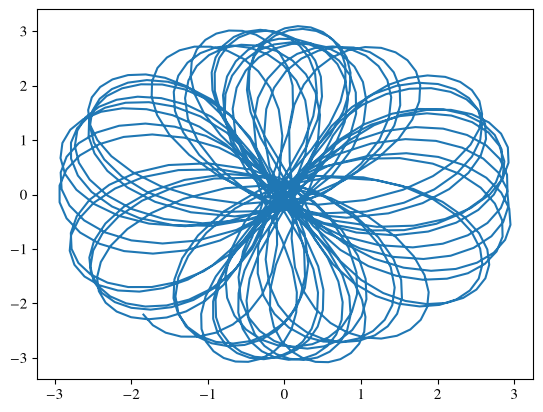

In [31]:
particleindex=24
fig,axis=plt.subplots(1,1)
axis.plot(orbits[particleindex,:,0],orbits[particleindex,:,1])
